# 📉 Statistical Arbitrage Backtester — Pairs Trading with Cointegration

This notebook builds a complete pairs-trading research pipeline:

1. **Sanity check on synthetic data**: why correlation is misleading and cointegration isn't.
2. **Pair screening**: test every same-sector pair for cointegration using only the *formation period*.
3. **Backtest**: trade the best pairs on a *separate, later* trading period, with no look-ahead.
4. **Realistic costs**: commissions, bid-ask spread, slippage and short-borrow fees.
5. **Analysis**: Sharpe, drawdown, win rate, cost sensitivity, static vs. rolling hedge ratio, and an equal-weight portfolio.

**To run:** `Runtime → Run all`. Every parameter you might want to change is in the **Configuration** cell.

In [1]:
!pip install -q yfinance statsmodels

In [2]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.regression.rolling import RollingOLS
import yfinance as yf

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", "{:.4f}".format)

## ⚙️ Configuration

The data is split into two non-overlapping periods:

- **Formation period**: used *only* to choose pairs and estimate hedge ratios.
- **Trading period**: the strategy is tested here on data it has never seen.

Mixing the two is the most common way pairs-trading backtests produce fake profits.

In [3]:
# ---- Periods ----
FORMATION_START = "2019-01-01"
FORMATION_END   = "2022-12-31"
TRADING_START   = "2023-01-01"
TRADING_END     = "2026-09-30"

# ---- Universe: pairs are only formed WITHIN a sector ----
SECTORS = {
    "US Beverages":   ["KO", "PEP", "KDP", "MNST"],
    "US Oil Majors":  ["XOM", "CVX", "COP", "BP", "SHEL"],
    "US Banks":       ["JPM", "BAC", "WFC", "C"],
    "US Payments":    ["V", "MA"],
    "US Home Improv": ["HD", "LOW"],
    "India Banks":    ["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS", "AXISBANK.NS", "SBIN.NS"],
    "India IT":       ["TCS.NS", "INFY.NS", "WIPRO.NS", "HCLTECH.NS", "TECHM.NS"],
}

# ---- Pair selection ----
P_VALUE_CUTOFF = 0.05          # Engle-Granger cointegration p-value
HALF_LIFE_RANGE = (1, 60)      # days; too fast = noise, too slow = capital tied up
TOP_N_PAIRS = 3

# ---- Trading rules (z-score of the spread) ----
Z_WINDOW = 60     # rolling window for mean/std, past data only
ENTRY_Z  = 2.0    # open a trade when |z| > ENTRY_Z
EXIT_Z   = 0.0    # close when z reverts back through ±EXIT_Z
STOP_Z   = 4.0    # stop-loss: the "leash" may have broken
ROLLING_BETA_WINDOW = 120  # for the rolling hedge-ratio comparison

# ---- Cost model (1 bp = 0.01%) ----
COMMISSION_BPS  = 1.0    # per unit of notional traded
HALF_SPREAD_BPS = 2.0    # crossing half the bid-ask spread
SLIPPAGE_BPS    = 2.0    # price moving against you as you execute
BORROW_RATE_ANNUAL = 0.01  # fee for borrowing the stock you short

COST_BPS = COMMISSION_BPS + HALF_SPREAD_BPS + SLIPPAGE_BPS
TRADING_DAYS = 252

## 1. Why correlation isn't enough: a synthetic experiment

Stock prices behave roughly like **random walks**: they wander with no fixed level to return to. Two random walks can be **cointegrated**, meaning some combination $A - \beta B$ keeps returning to a mean. A common picture is a drunk walking a dog on a leash: each path is unpredictable, but the distance between them can't grow forever.

Below we simulate 500 pairs of *completely unrelated* random walks and measure (a) their correlation and (b) the Engle-Granger cointegration p-value. A trustworthy test should flag only about 5% of these as "related" at the 5% level.

Unrelated walks with |correlation| > 0.5:  40.6%
Unrelated walks with coint p-value < 0.05: 7.6%   (should be ~5%)
Truly cointegrated pair -> coint p-value: 0.000000


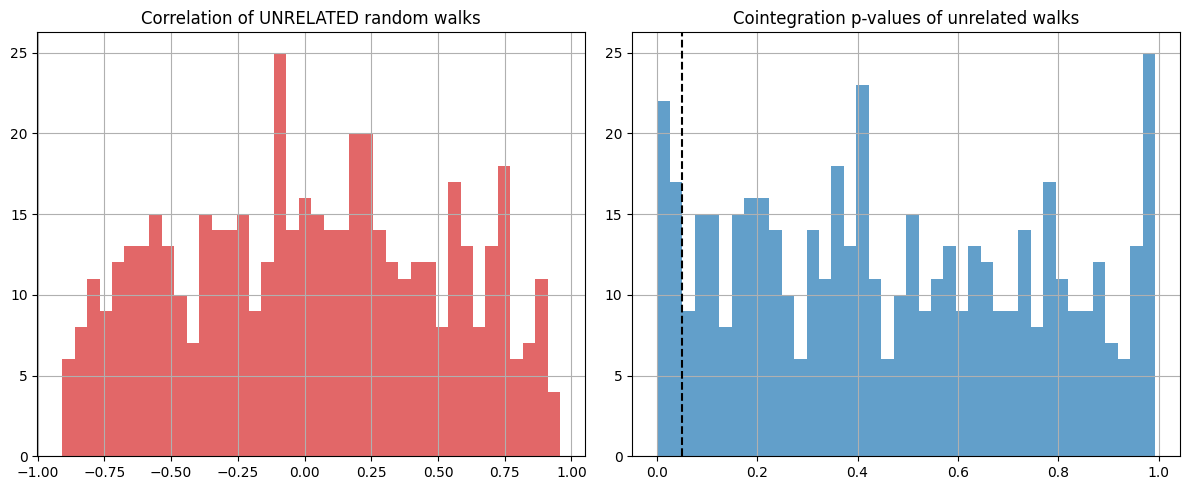

In [4]:
rng = np.random.default_rng(42)
N_DAYS, N_SIMS = 1000, 500

corrs, pvals = [], []
for _ in range(N_SIMS):
    a = pd.Series(np.cumsum(rng.normal(size=N_DAYS)))
    b = pd.Series(np.cumsum(rng.normal(size=N_DAYS)))
    corrs.append(a.corr(b))
    pvals.append(coint(a, b)[1])
corrs, pvals = np.array(corrs), np.array(pvals)

print(f"Unrelated walks with |correlation| > 0.5:  {np.mean(np.abs(corrs) > 0.5):.1%}")
print(f"Unrelated walks with coint p-value < 0.05: {np.mean(pvals < 0.05):.1%}   (should be ~5%)")

# A pair that IS cointegrated by construction
x = pd.Series(np.cumsum(rng.normal(size=N_DAYS)))
y = 2 * x + rng.normal(scale=3, size=N_DAYS)
print(f"Truly cointegrated pair -> coint p-value: {coint(y, x)[1]:.6f}")

fig, axes = plt.subplots(1, 2)
axes[0].hist(corrs, bins=40, color="tab:red", alpha=0.7)
axes[0].set_title("Correlation of UNRELATED random walks")
axes[1].hist(pvals, bins=40, color="tab:blue", alpha=0.7)
axes[1].axvline(0.05, ls="--", c="k")
axes[1].set_title("Cointegration p-values of unrelated walks")
plt.tight_layout(); plt.show()

**Takeaway:** a large share of unrelated random walks show strong correlation purely by chance (this is called *spurious regression*). The cointegration test is far better behaved: only about 5% false positives. That 5% still matters, though. When we screen dozens of pairs below, a few will pass by luck alone. This is the **multiple-testing problem**, and it's why the trading period must be separate from the formation period.

## 2. Download price data

Each sector is downloaded separately, because US and Indian markets have different trading holidays.

In [5]:
import time

def _fetch(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, auto_adjust=True,
                     progress=False, threads=False)["Close"]
    return df.to_frame(name=tickers[0]) if isinstance(df, pd.Series) else df

def download_prices(tickers, start, end, retries=3):
    df = _fetch(tickers, start, end)
    for _ in range(retries):            # Yahoo sometimes fails a ticker at random: retry it
        missing = [t for t in tickers if t not in df.columns or df[t].isna().all()]
        if not missing:
            break
        time.sleep(2)
        retry = _fetch(missing, start, end)
        for t in retry.columns:
            df[t] = retry[t]
    missing = [t for t in tickers if t not in df.columns or df[t].isna().all()]
    if missing:
        print(f"⚠️ Could not download {missing}; rerun this cell to try again.")
    df = df.dropna(axis=1, how="all")   # drop tickers that still failed
    return df.dropna()                  # keep only days where every ticker traded

prices = {}
for sector, tickers in SECTORS.items():
    df = download_prices(tickers, FORMATION_START, TRADING_END)
    if df.shape[1] >= 2:
        prices[sector] = df
    print(f"{sector:16s} {df.shape[0]:5d} days | {', '.join(df.columns)}")

US Beverages      1946 days | KDP, KO, MNST, PEP
US Oil Majors     1946 days | BP, COP, CVX, SHEL, XOM
US Banks          1946 days | BAC, C, JPM, WFC
US Payments       1946 days | MA, V
US Home Improv    1946 days | HD, LOW
India Banks       1918 days | AXISBANK.NS, HDFCBANK.NS, ICICIBANK.NS, KOTAKBANK.NS, SBIN.NS
India IT          1918 days | HCLTECH.NS, INFY.NS, TCS.NS, TECHM.NS, WIPRO.NS


## 3. Screening pairs (formation period only)

For every pair (A, B) within a sector, using **log prices** from the formation period:

1. **Engle-Granger test** (`coint`): is there a β that makes $\log A - \beta \log B$ stationary?
2. **Hedge ratio** β from the OLS regression $\log A = \alpha + \beta \log B$. With log prices, β means roughly "a 1% move in B corresponds to a β% move in A."
3. **Half-life of mean reversion.** We regress the daily change in the spread on yesterday's spread, $\Delta s_t = c + \lambda s_{t-1}$. Then the half-life is $-\ln 2 / \lambda$, the typical number of days for a gap to close halfway.

> **Subtlety:** running a plain ADF test on the regression residuals gives p-values that are *too optimistic*, because β was chosen to make the residuals look as stationary as possible. `coint()` corrects for this with different critical values, which is why we use it.

In [6]:
def hedge_ratio(y, x):
    # OLS: y = alpha + beta * x.  Returns (alpha, beta).
    params = sm.OLS(y, sm.add_constant(x)).fit().params
    return params.iloc[0], params.iloc[1]

def half_life(spread):
    lagged = spread.shift(1).dropna()
    delta = spread.diff().dropna()
    lam = sm.OLS(delta, sm.add_constant(lagged)).fit().params.iloc[1]
    return -np.log(2) / lam if lam < 0 else np.inf

rows = []
for sector, df in prices.items():
    formation = np.log(df.loc[FORMATION_START:FORMATION_END])
    for a, b in itertools.combinations(df.columns, 2):
        y, x = formation[a], formation[b]
        alpha, beta = hedge_ratio(y, x)
        rows.append({
            "sector": sector, "A": a, "B": b,
            "corr": y.corr(x),
            "coint_p": coint(y, x)[1],
            "alpha": alpha, "beta": beta,
            "half_life": half_life(y - alpha - beta * x),
        })

screen = pd.DataFrame(rows).sort_values("coint_p").reset_index(drop=True)
n_tests = len(screen)
print(f"Pairs tested: {n_tests}")
print(f"Pass at p < {P_VALUE_CUTOFF}: {(screen.coint_p < P_VALUE_CUTOFF).sum()}  "
      f"(expected by pure chance: ~{n_tests * P_VALUE_CUTOFF:.1f})")
print(f"Pass Bonferroni-corrected p < {P_VALUE_CUTOFF / n_tests:.4f}: "
      f"{(screen.coint_p < P_VALUE_CUTOFF / n_tests).sum()}")
screen.head(10)

Pairs tested: 44
Pass at p < 0.05: 5  (expected by pure chance: ~2.2)
Pass Bonferroni-corrected p < 0.0011: 1


,sector,A,B,corr,coint_p,alpha,beta,half_life
0,India IT,INFY.NS,TCS.NS,0.9861,0.0000,-4.6303,1.4833,15.6148
1,India IT,HCLTECH.NS,TCS.NS,0.9883,0.0018,-3.9849,1.3468,12.6748
2,India IT,HCLTECH.NS,INFY.NS,0.9869,0.0044,0.3144,0.8941,20.2269
3,US Payments,MA,V,0.9821,0.0136,-0.4223,1.1716,16.2655
4,India Banks,HDFCBANK.NS,KOTAKBANK.NS,0.9373,0.0142,0.6280,0.9994,20.4417
5,US Oil Majors,COP,CVX,0.9772,0.0612,-2.5141,1.4318,29.2396
6,US Beverages,KO,PEP,0.9261,0.0618,0.0323,0.7887,37.7408
7,US Home Improv,HD,LOW,0.9739,0.0648,2.0017,0.6977,34.3819
8,US Oil Majors,CVX,XOM,0.9710,0.0933,1.3933,0.7897,34.0824
9,India Banks,KOTAKBANK.NS,SBIN.NS,0.7792,0.1201,3.8809,0.3308,37.7620


In [7]:
lo, hi = HALF_LIFE_RANGE
candidates = screen[
    (screen.coint_p < P_VALUE_CUTOFF)
    & screen.half_life.between(lo, hi)
    & (screen.beta > 0)
]

if len(candidates) == 0:
    print("⚠️ No pair passed all filters. Using the lowest p-value pairs anyway, "
          "so treat these results as a negative finding, not a strategy.")
    candidates = screen[screen.beta > 0]

selected = candidates.head(TOP_N_PAIRS).reset_index(drop=True)
selected

,sector,A,B,corr,coint_p,alpha,beta,half_life
0,India IT,INFY.NS,TCS.NS,0.9861,0.0000,-4.6303,1.4833,15.6148
1,India IT,HCLTECH.NS,TCS.NS,0.9883,0.0018,-3.9849,1.3468,12.6748
2,India IT,HCLTECH.NS,INFY.NS,0.9869,0.0044,0.3144,0.8941,20.2269


## 4. The backtest engine

**Signal** (computed at each day's close, using only past data):

$$z_t = \frac{s_t - \text{rolling mean}(s)}{\text{rolling std}(s)}, \qquad s_t = \log A_t - \alpha - \beta \log B_t$$

| Condition | Action |
|---|---|
| $z > +2$ | **Short the spread**: sell A, buy β of B |
| $z < -2$ | **Long the spread**: buy A, sell β of B |
| $z$ reverts through ±EXIT_Z | Close the trade |
| $|z| > 4$ | Stop-loss; no re-entry until $|z| < 2$ again |

**Execution:** a signal at day *t*'s close is held from day *t+1*, implemented with `.shift(1)`. Without that shift, the backtest would trade on prices it couldn't have known yet.

**Position sizing:** \$1 in A and \$β in B, scaled so total gross exposure equals our capital.

**Costs:**
- Each change in position pays `COST_BPS` on the notional traded.
- Every day a position is open, the short leg pays a borrow fee.

In [8]:
def build_positions(z):
    pos = np.zeros(len(z))
    current, stopped = 0, False
    for i, zt in enumerate(z.values):
        if np.isnan(zt):
            pos[i] = current
            continue
        if stopped and abs(zt) < ENTRY_Z:
            stopped = False                      # spread is back to normal: re-arm
        if current == 0 and not stopped:
            if zt > ENTRY_Z:
                current = -1                     # spread too high -> short it
            elif zt < -ENTRY_Z:
                current = 1                      # spread too low -> buy it
        elif current == 1:
            if zt < -STOP_Z:
                current, stopped = 0, True
            elif zt >= -EXIT_Z:
                current = 0
        elif current == -1:
            if zt > STOP_Z:
                current, stopped = 0, True
            elif zt <= EXIT_Z:
                current = 0
        pos[i] = current
    return pd.Series(pos, index=z.index)


def backtest_pair(df, a, b, alpha, beta, cost_bps=COST_BPS, rolling_beta=False):
    logp = np.log(df[[a, b]])

    if rolling_beta:
        fit = RollingOLS(logp[a], sm.add_constant(logp[b]), window=ROLLING_BETA_WINDOW).fit()
        alpha_s, beta_s = fit.params["const"], fit.params[b]
    else:
        alpha_s = pd.Series(alpha, index=df.index)
        beta_s = pd.Series(beta, index=df.index)

    spread = logp[a] - alpha_s - beta_s * logp[b]
    z_full = (spread - spread.rolling(Z_WINDOW).mean()) / spread.rolling(Z_WINDOW).std()

    z = z_full.loc[TRADING_START:TRADING_END]
    pos = build_positions(z)
    held = pos.shift(1).fillna(0)                          # trade at close t, hold from t+1
    beta_held = beta_s.loc[z.index].shift(1).bfill()       # hedge ratio when the trade was set

    rets = df[[a, b]].pct_change().loc[z.index].fillna(0)
    gross_exposure = 1 + beta_held.abs()
    gross = held * (rets[a] - beta_held * rets[b]) / gross_exposure

    traded = pos.diff().fillna(pos.iloc[0]).abs()          # fraction of capital traded
    trading_cost = traded * cost_bps / 1e4

    short_frac = np.where(held > 0, beta_held / gross_exposure,      # long spread: B is short
                 np.where(held < 0, 1 / gross_exposure, 0.0))        # short spread: A is short
    borrow_cost = short_frac * BORROW_RATE_ANNUAL / TRADING_DAYS

    net = gross - trading_cost - borrow_cost
    return pd.DataFrame({
        "z": z, "pos": pos, "held": held, "beta": beta_held,
        "gross": gross, "trading_cost": trading_cost,
        "borrow_cost": borrow_cost, "net": net,
    })

In [9]:
def trade_returns(bt, cost_bps=COST_BPS):
    # Return of each completed round-trip trade, net of entry + exit costs.
    held = bt["held"]
    entry = (held != 0) & (held.shift(1).fillna(0) == 0)
    trade_id = entry.cumsum()[held != 0]
    per_trade = bt["gross"][held != 0].groupby(trade_id).apply(lambda r: (1 + r).prod() - 1)
    return per_trade - 2 * cost_bps / 1e4


def performance(bt, cost_bps=COST_BPS):
    r = bt["net"]
    equity = (1 + r).cumprod()
    years = len(r) / TRADING_DAYS
    trades = trade_returns(bt, cost_bps)
    gross_sharpe = bt["gross"].mean() / bt["gross"].std() * np.sqrt(TRADING_DAYS) if bt["gross"].std() > 0 else np.nan
    return {
        "Total return": equity.iloc[-1] - 1,
        "Annual return": equity.iloc[-1] ** (1 / years) - 1,
        "Annual vol": r.std() * np.sqrt(TRADING_DAYS),
        "Sharpe (net)": r.mean() / r.std() * np.sqrt(TRADING_DAYS) if r.std() > 0 else np.nan,
        "Sharpe (gross)": gross_sharpe,
        "Max drawdown": (equity / equity.cummax() - 1).min(),
        "Trades": len(trades),
        "Win rate": (trades > 0).mean() if len(trades) else np.nan,
        "Time in market": (bt["held"] != 0).mean(),
        "Total costs": (bt["trading_cost"] + bt["borrow_cost"]).sum(),
    }

## 5. Run the backtest on the selected pairs

In [10]:
results, backtests = {}, {}
for _, row in selected.iterrows():
    name = f"{row.A} / {row.B}"
    bt = backtest_pair(prices[row.sector], row.A, row.B, row.alpha, row.beta)
    backtests[name] = bt
    results[name] = performance(bt)

summary = pd.DataFrame(results).T
summary

,Total return,Annual return,Annual vol,Sharpe (net),Sharpe (gross),Max drawdown,Trades,Win rate,Time in market,Total costs
INFY.NS / TCS.NS,0.1022,0.0268,0.0711,0.4073,0.5061,-0.0796,16.0000,0.6250,0.5765,0.0263
HCLTECH.NS / TCS.NS,0.1281,0.0333,0.0715,0.4936,0.5837,-0.0849,16.0000,0.6875,0.5356,0.0244
HCLTECH.NS / INFY.NS,-0.1228,-0.0350,0.0793,-0.4089,-0.3169,-0.1768,14.0000,0.5000,0.6929,0.0266


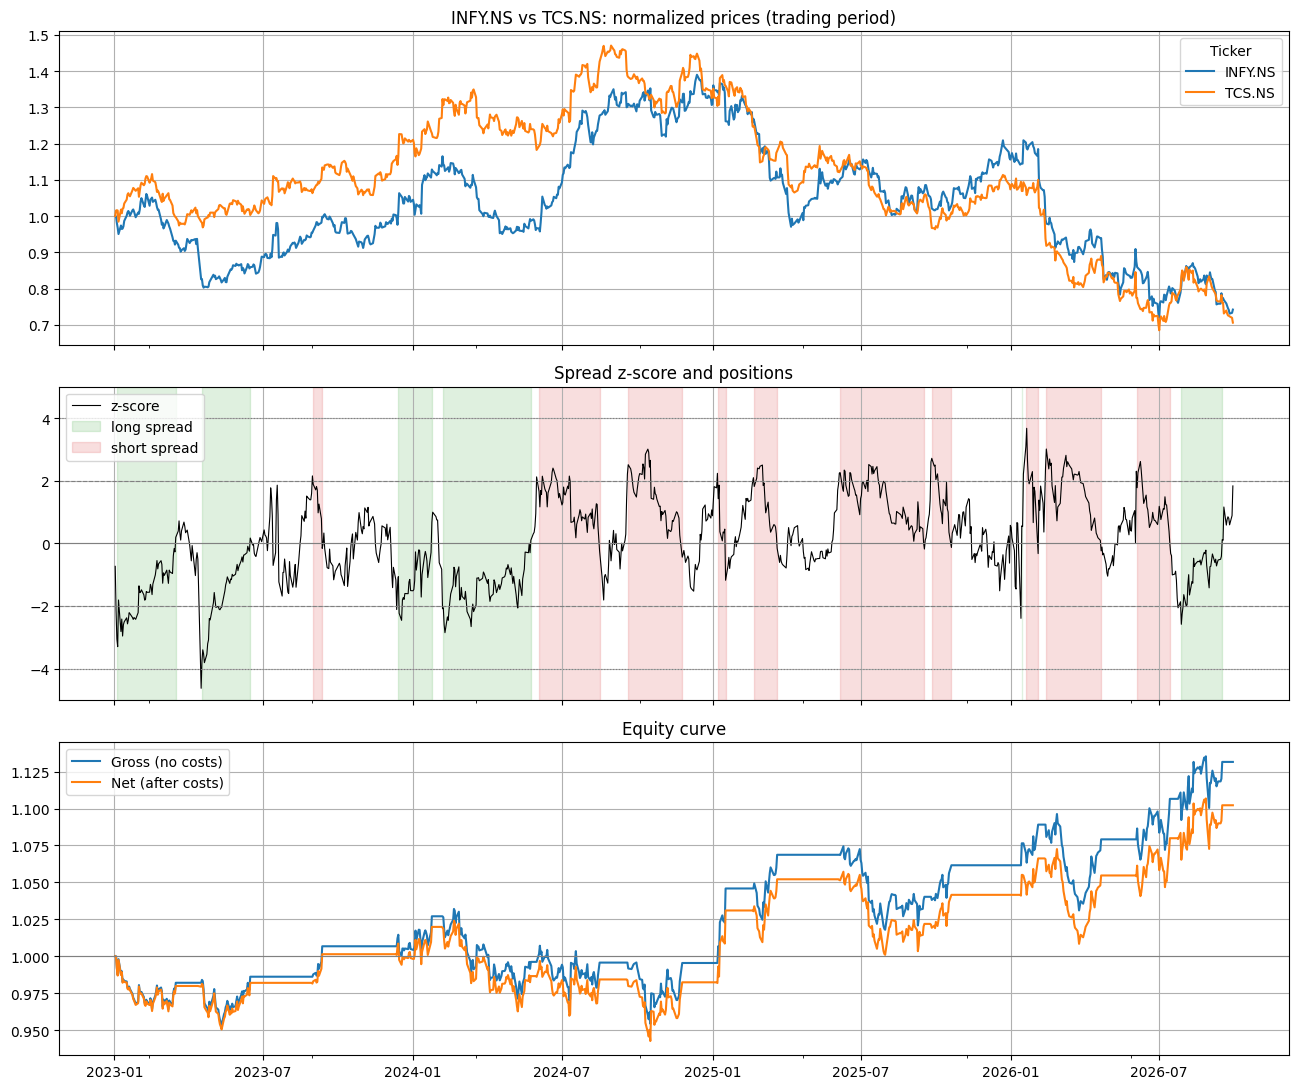

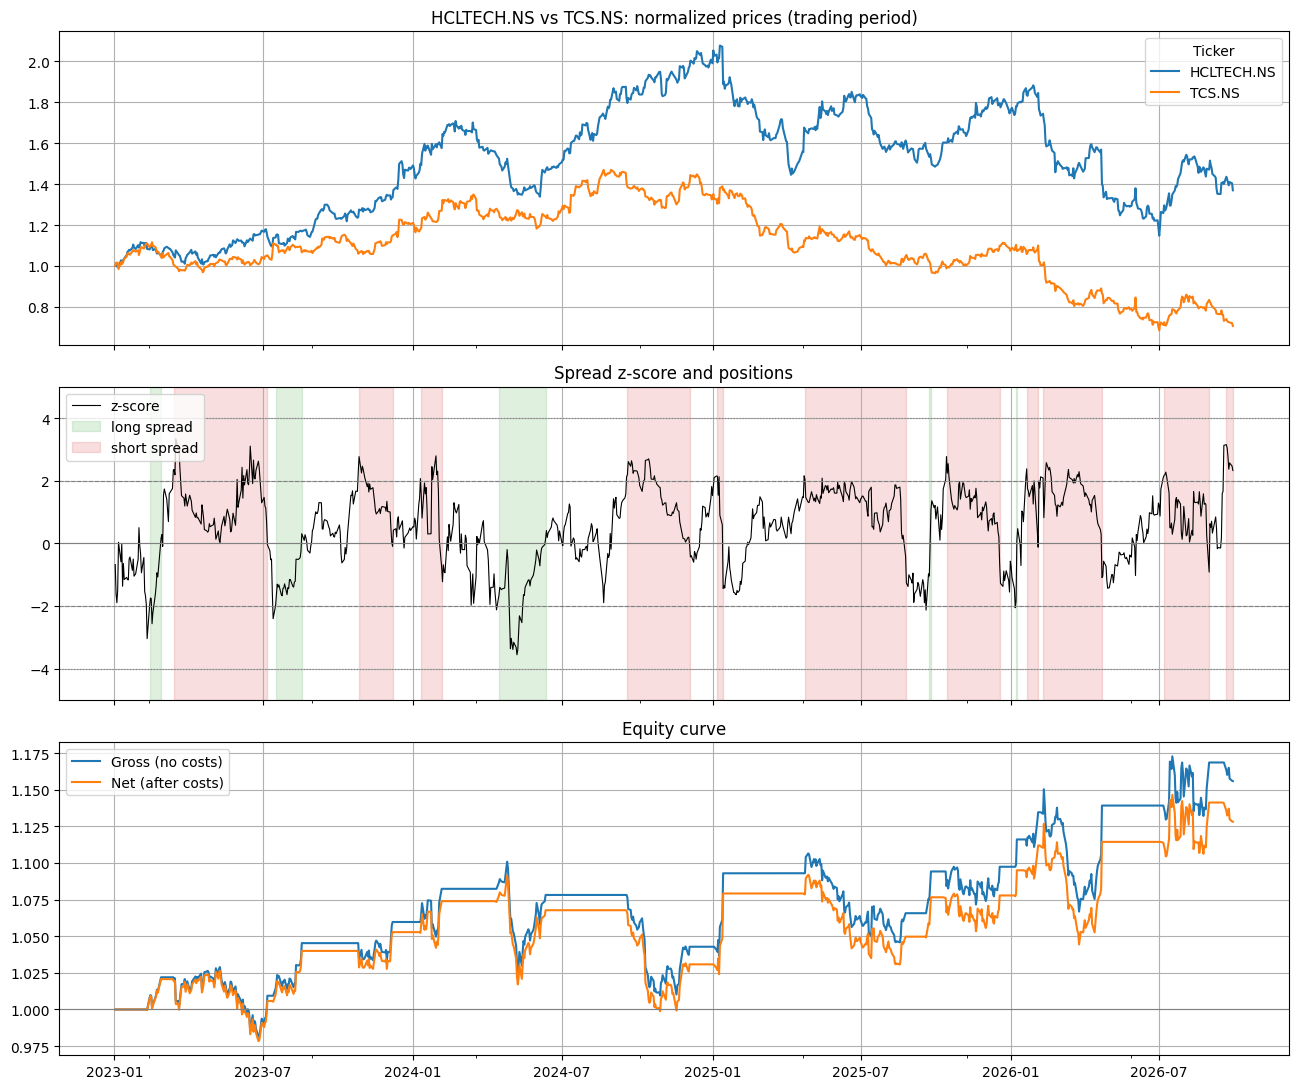

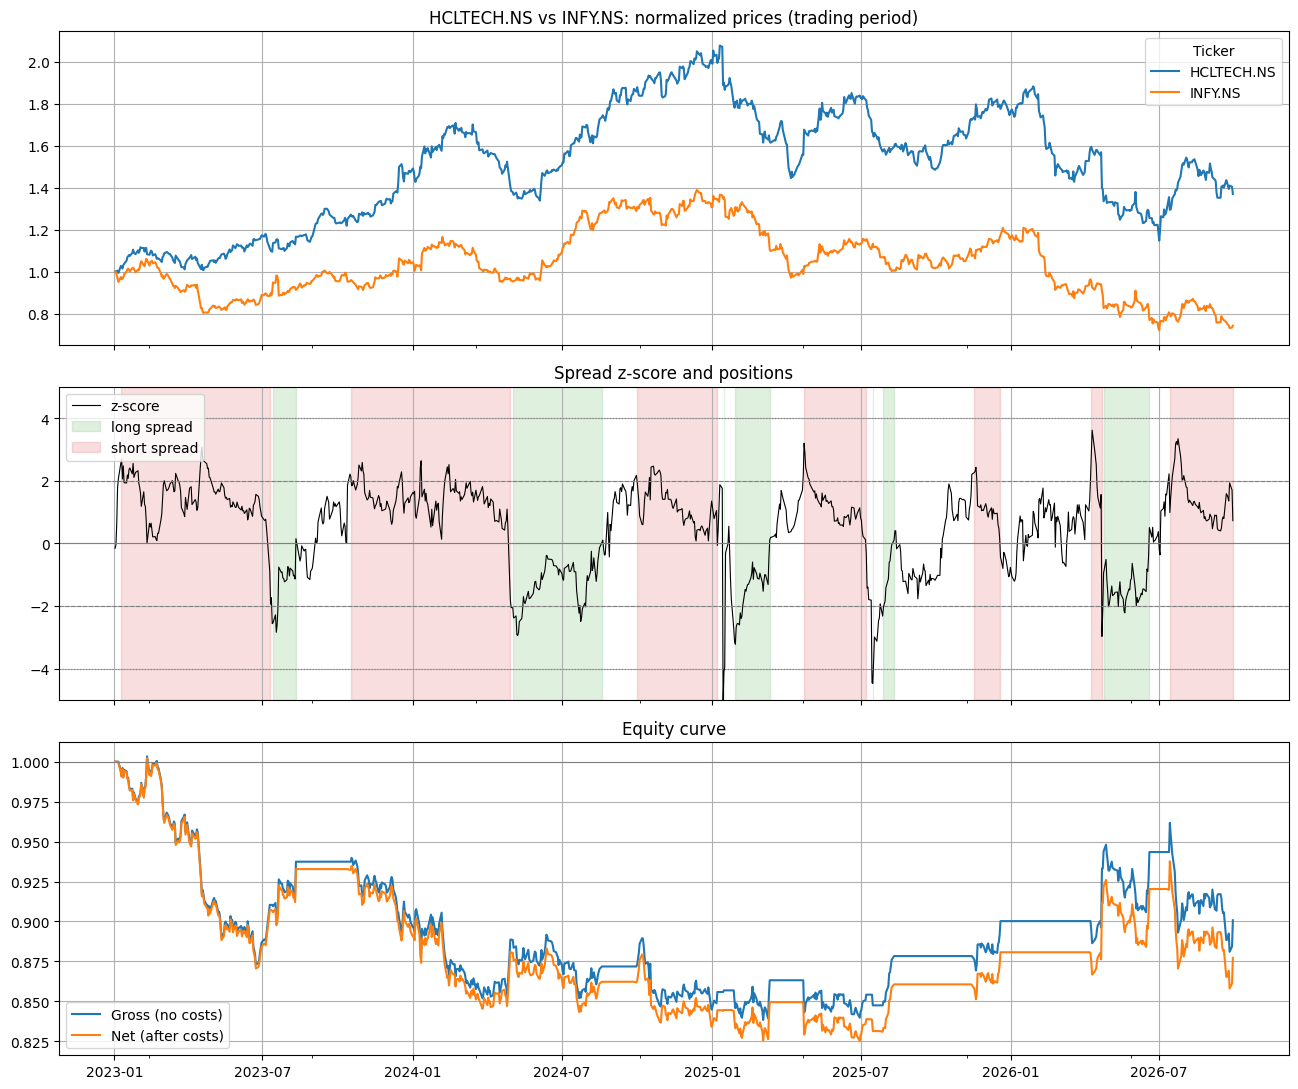

In [11]:
def plot_pair(row, bt):
    df = prices[row.sector].loc[TRADING_START:TRADING_END]
    fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

    (df[[row.A, row.B]] / df[[row.A, row.B]].iloc[0]).plot(ax=axes[0])
    axes[0].set_title(f"{row.A} vs {row.B}: normalized prices (trading period)")

    axes[1].plot(bt.index, bt["z"], c="k", lw=0.8, label="z-score")
    for lvl, style in [(ENTRY_Z, "--"), (-ENTRY_Z, "--"), (STOP_Z, ":"), (-STOP_Z, ":"), (0, "-")]:
        axes[1].axhline(lvl, ls=style, c="grey", lw=0.8)
    axes[1].fill_between(bt.index, -5, 5, where=bt["held"] > 0, color="tab:green", alpha=0.15, label="long spread")
    axes[1].fill_between(bt.index, -5, 5, where=bt["held"] < 0, color="tab:red", alpha=0.15, label="short spread")
    axes[1].set_ylim(-5, 5); axes[1].legend(loc="upper left")
    axes[1].set_title("Spread z-score and positions")

    axes[2].plot((1 + bt["gross"]).cumprod(), label="Gross (no costs)")
    axes[2].plot((1 + bt["net"]).cumprod(), label="Net (after costs)")
    axes[2].axhline(1, c="grey", lw=0.8); axes[2].legend()
    axes[2].set_title("Equity curve")
    plt.tight_layout(); plt.show()

for _, row in selected.iterrows():
    plot_pair(row, backtests[f"{row.A} / {row.B}"])

## 6. How much do transaction costs matter?

We rerun the best pair across a range of total costs, from 0 bps (a fantasy) to 30 bps. This is often the most revealing chart in a pairs-trading study. Many strategies that look excellent at 0 bps disappear at realistic retail costs.

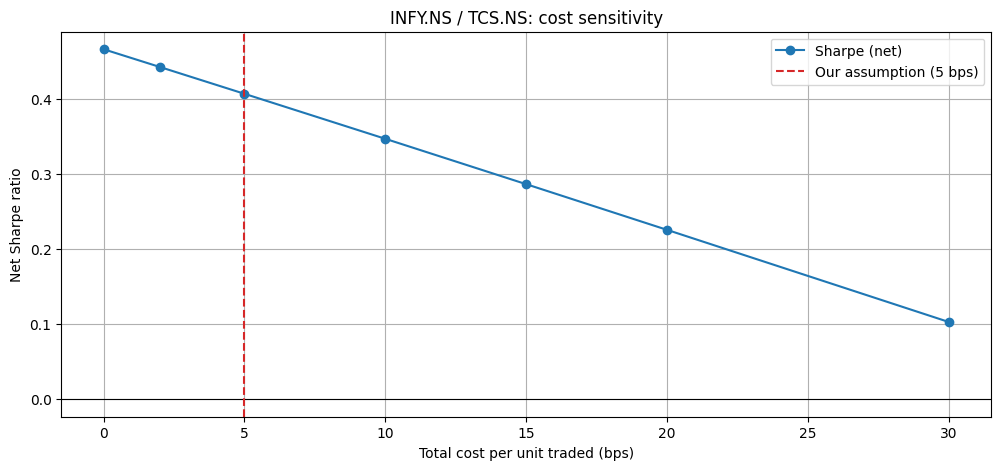

Break-even cost: above 30 bps


,Sharpe (net),Annual return
cost_bps,,
0,0.4667,0.0312
2,0.4430,0.0295
5,0.4073,0.0268
10,0.3473,0.0223
15,0.2867,0.0179
20,0.2258,0.0135
30,0.1029,0.0048


In [12]:
best = selected.iloc[0]
cost_grid = [0, 2, 5, 10, 15, 20, 30]
sens = []
for c in cost_grid:
    bt = backtest_pair(prices[best.sector], best.A, best.B, best.alpha, best.beta, cost_bps=c)
    p = performance(bt, cost_bps=c)
    sens.append({"cost_bps": c, "Sharpe (net)": p["Sharpe (net)"], "Annual return": p["Annual return"]})
sens = pd.DataFrame(sens).set_index("cost_bps")

fig, ax = plt.subplots()
sens["Sharpe (net)"].plot(marker="o", ax=ax)
ax.axhline(0, c="k", lw=0.8)
ax.axvline(COST_BPS, ls="--", c="tab:red", label=f"Our assumption ({COST_BPS:.0f} bps)")
ax.set_xlabel("Total cost per unit traded (bps)"); ax.set_ylabel("Net Sharpe ratio")
ax.set_title(f"{best.A} / {best.B}: cost sensitivity"); ax.legend()
plt.show()

be = sens[sens["Sharpe (net)"] <= 0]
print("Break-even cost:", f"~{be.index[0]} bps" if len(be) else f"above {cost_grid[-1]} bps")
sens

## 7. Static vs. rolling hedge ratio

Relationships between companies drift over time. Instead of fixing β from the formation period, we can re-estimate it every day using the last 120 days of data. This still uses past data only, so there's no look-ahead.

In [13]:
compare = {}
for _, row in selected.iterrows():
    name = f"{row.A} / {row.B}"
    bt_roll = backtest_pair(prices[row.sector], row.A, row.B, row.alpha, row.beta, rolling_beta=True)
    compare[(name, "static β")] = performance(backtests[name])
    compare[(name, "rolling β")] = performance(bt_roll)

pd.DataFrame(compare).T[["Annual return", "Sharpe (net)", "Max drawdown", "Trades", "Win rate"]]

Annual return  Sharpe (net)  Max drawdown  \
INFY.NS / TCS.NS     static β          0.0268        0.4073       -0.0796   
                     rolling β        -0.0070       -0.0850       -0.1450   
HCLTECH.NS / TCS.NS  static β          0.0333        0.4936       -0.0849   
                     rolling β        -0.0310       -0.3856       -0.2303   
HCLTECH.NS / INFY.NS static β         -0.0350       -0.4089       -0.1768   
                     rolling β         0.0014        0.0548       -0.1410   

                                Trades  Win rate  
INFY.NS / TCS.NS     static β  16.0000    0.6250  
                     rolling β 16.0000    0.5625  
HCLTECH.NS / TCS.NS  static β  16.0000    0.6875  
                     rolling β 17.0000    0.5882  
HCLTECH.NS / INFY.NS static β  14.0000    0.5000  
                     rolling β 15.0000    0.6000

## 8. Equal-weight portfolio of pairs

Spreading capital across several pairs reduces the damage when any single relationship breaks down.

Annual return    0.0095
Annual vol       0.0488
Sharpe (net)     0.2172
Sharpe (gross)   0.3596
Max drawdown    -0.0681


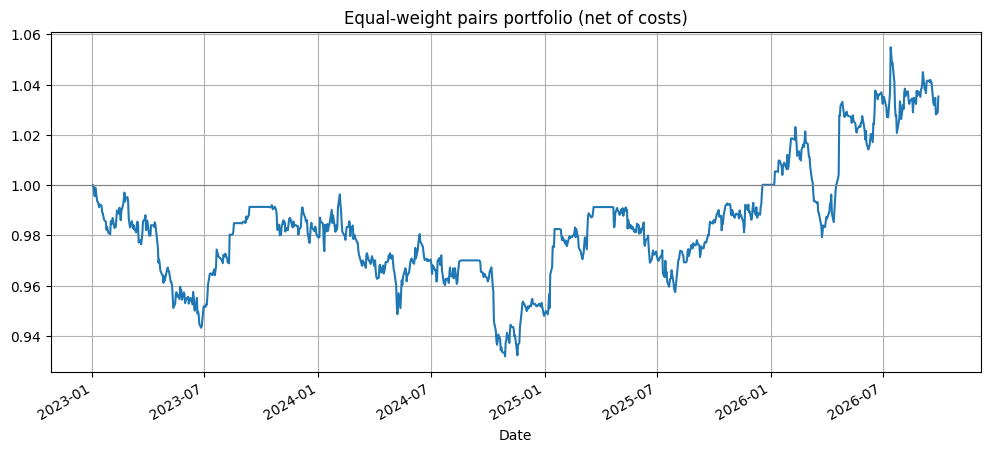

In [14]:
port_net = pd.concat({k: v["net"] for k, v in backtests.items()}, axis=1).fillna(0).mean(axis=1)
port_gross = pd.concat({k: v["gross"] for k, v in backtests.items()}, axis=1).fillna(0).mean(axis=1)

port_bt = pd.DataFrame({"net": port_net, "gross": port_gross,
                        "held": 1.0, "trading_cost": 0.0, "borrow_cost": 0.0})
p = performance(port_bt)
for k in ["Annual return", "Annual vol", "Sharpe (net)", "Sharpe (gross)", "Max drawdown"]:
    print(f"{k:15s} {p[k]: .4f}")

(1 + port_net).cumprod().plot(title="Equal-weight pairs portfolio (net of costs)")
plt.axhline(1, c="grey", lw=0.8); plt.show()

## 9. Limitations (keep these in your write-up)

- **Survivorship bias:** the universe uses companies that still exist today. Pairs where one company went bankrupt or was acquired are missing.
- **Shorting in India:** retail investors in India can't hold an overnight short in cash equities. In practice the short leg needs stock futures or the SLB (securities lending and borrowing) mechanism, which have their own costs. India also charges STT and other taxes, so a realistic Indian cost assumption is higher than our default.
- **Data quality:** Yahoo Finance prices are free and can contain errors. Adjusted prices also bake in dividends in a simplified way.
- **Static universe and parameters:** the entry, exit and window settings were picked by hand. Tuning them on the trading period would be overfitting.
- **Execution:** we assume trades fill at the closing price. Real fills differ.

## 10. Possible extensions

- A **Kalman filter** hedge ratio, which updates β smoothly as each new price arrives.
- The **Johansen test**, for trading baskets of three or more stocks.
- A **walk-forward** design: re-screen pairs every year and trade the following year, repeating through time.
- **Volatility-scaled position sizing.**